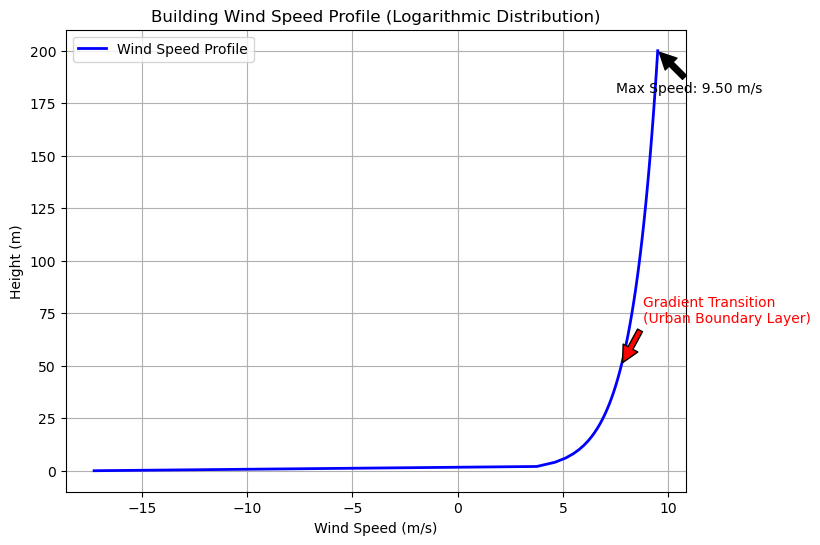

In [1]:
import numpy as np  # For numerical operations and data generation
import matplotlib.pyplot as plt  # For creating the plot

# Step 1: Define parameters for the building wind process
# Assume a tall building of 200 meters height.
# Wind speed profile follows a logarithmic law: U(z) = (u*/k) * ln(z/z0),
# where u* is friction velocity, k is von Karman constant (0.4), z0 is roughness length.
height = np.linspace(0, 200, 100)  # Heights from 0 to 200m, 100 points for smooth curve
u_star = 0.5  # Friction velocity (m/s), example value
k = 0.4  # von Karman constant
z0 = 0.1  # Roughness length (m) for urban area, example value

# Step 2: Calculate wind speeds based on the logarithmic profile
# Avoid log(0) by starting from a small offset if needed; here linspace starts at 0 but we clip.
wind_speed = (u_star / k) * np.log(height / z0 + 1e-6)  # Add small epsilon to avoid log(0)

# Step 3: Create the profile plot
plt.figure(figsize=(8, 6))  # Set figure size for better readability
plt.plot(wind_speed, height, label='Wind Speed Profile', color='blue', linewidth=2)  # Plot speed on x, height on y (vertical profile)
plt.xlabel('Wind Speed (m/s)')  # Label x-axis
plt.ylabel('Height (m)')  # Label y-axis
plt.title('Building Wind Speed Profile (Logarithmic Distribution)')  # Title for context
plt.grid(True)  # Add grid for reference
plt.legend()  # Show legend

# Step 4: Add annotations for key points
# Annotate maximum wind speed at top height
max_speed = wind_speed[-1]
plt.annotate(f'Max Speed: {max_speed:.2f} m/s', 
             xy=(max_speed, height[-1]), 
             xytext=(max_speed - 2, height[-1] - 20),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10)

# Annotate a gradient change point (e.g., at 50m height)
mid_index = np.argmin(np.abs(height - 50))  # Find index closest to 50m
mid_speed = wind_speed[mid_index]
plt.annotate('Gradient Transition\n(Urban Boundary Layer)', 
             xy=(mid_speed, height[mid_index]), 
             xytext=(mid_speed + 1, height[mid_index] + 20),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10,
             color='red')

# Step 5: Display or save the plot
# In a script, use plt.show() to display; or plt.savefig('wind_profile.png') to save.
plt.show()  # Uncomment to display in an interactive environment
# plt.savefig('building_wind_profile.png')  # Optional: Save as image file

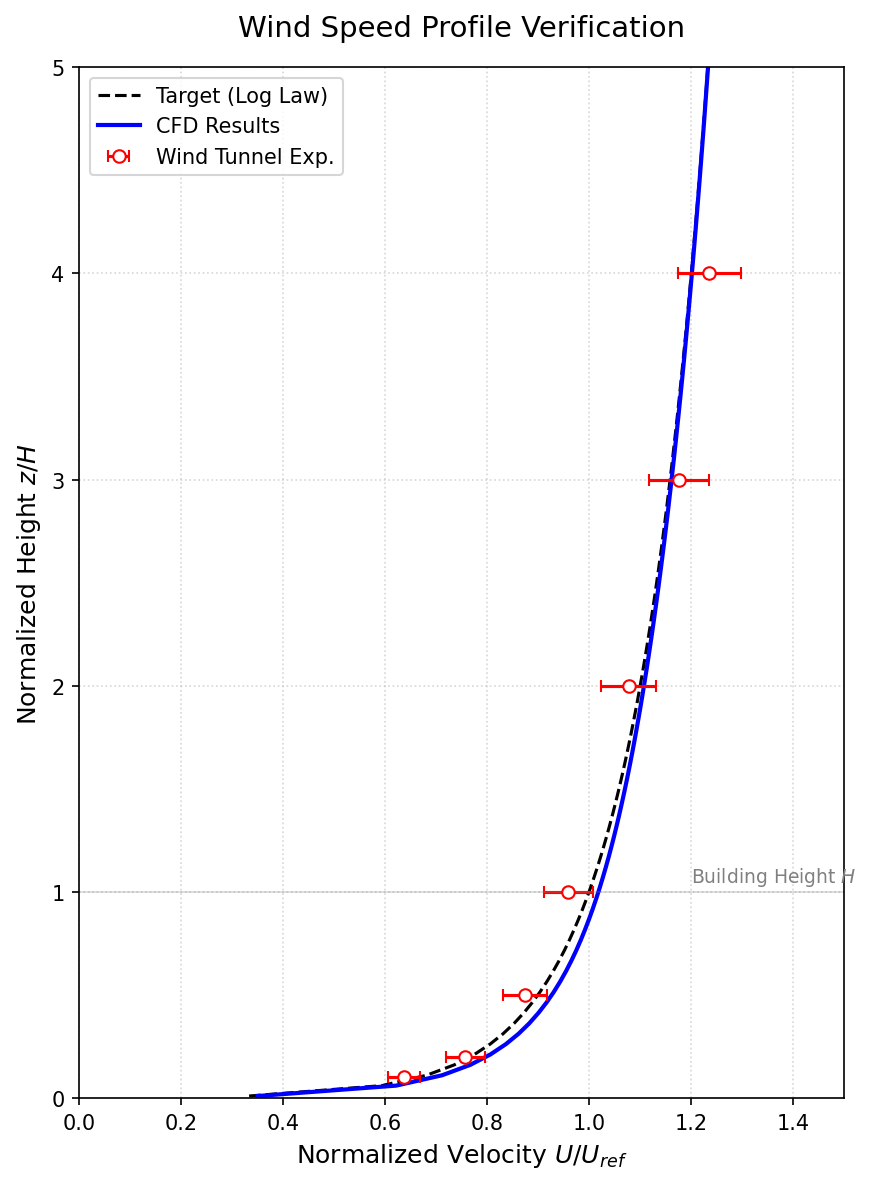

In [2]:
# 1. 物理参数与数据准备 (模拟 Tominaga 实验室常见场景)
# ----------------------------------------------------------------
H = 0.1  # 建筑高度 (单位: m, 假设缩尺模型)
U_ref = 10.0  # 参考高度处的风速 (m/s)
z0 = 0.0001  # 地表粗糙度长度 (m)
kappa = 0.41  # 卡门常数
u_star = (U_ref * kappa) / np.log(H / z0)  # 摩擦速度

# 生成高度坐标 (从地面到 5 倍建筑高度)
z = np.linspace(0.001, 0.5, 100)

# 理论对数律剖面 (Log Law - 基准线)
U_log = (u_star / kappa) * np.log(z / z0)

# 模拟 CFD 计算结果 (带有一点偏差的曲线)
U_cfd = U_log * (1 + 0.05 * np.exp(-z/H)) 

# 模拟 实验观测数据 (EFD - 离散点)
z_exp = np.array([0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4])
U_exp = (u_star / kappa) * np.log(z_exp / z0) * (1 + np.random.normal(0, 0.03, len(z_exp)))
U_error = U_exp * 0.05  # 假设 5% 的实验误差棒

# ----------------------------------------------------------------
# 2. 绘图开始
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 8), dpi=150) # 纵向较长的图更适合剖面图

# 绘制理论基准线 (虚线)
ax.plot(U_log / U_ref, z / H, '--k', label='Target (Log Law)', linewidth=1.5)

# 绘制 CFD 结果 (实线)
ax.plot(U_cfd / U_ref, z / H, '-b', label='CFD Results', linewidth=2)

# 绘制 实验观测数据 (散点 + 误差棒)
ax.errorbar(U_exp / U_ref, z_exp / H, xerr=U_error / U_ref, 
            fmt='ro', mfc='white', mec='red', capsize=3, 
            label='Wind Tunnel Exp.', markersize=6)

# ----------------------------------------------------------------
# 3. 图表细节标准化设置
# ----------------------------------------------------------------

# 设置坐标轴范围
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 5)

# 标签使用 LaTeX 格式 (符合学术论文规范)
ax.set_xlabel(r'Normalized Velocity $U/U_{ref}$', fontsize=12)
ax.set_ylabel(r'Normalized Height $z/H$', fontsize=12)

# 开启网格 (辅助观察)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

# 图例设置 (放在合适的位置)
ax.legend(loc='upper left', frameon=True, fontsize=10)

# 设置标题
ax.set_title('Wind Speed Profile Verification', fontsize=14, pad=15)

# 辅助线：标出建筑高度 H 的位置
ax.axhline(y=1.0, color='gray', linestyle='-', linewidth=0.8, alpha=0.3)
ax.text(1.2, 1.05, 'Building Height $H$', color='gray', fontsize=9)

# ----------------------------------------------------------------
# 4. 布局调整与保存
# ----------------------------------------------------------------
plt.tight_layout()
# plt.savefig('Wind_Profile_Validation.png', bbox_inches='tight', dpi=300)
plt.show()

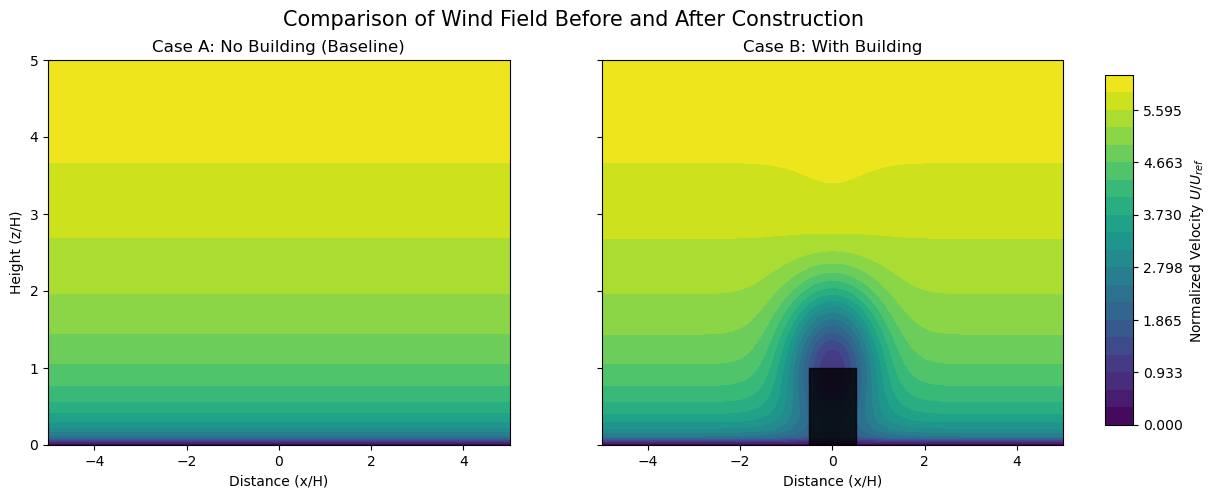

In [3]:
# 1. 模拟数据生成 (实际研究中请替换为读取的 CSV 或 OpenFOAM 数据)
# ----------------------------------------------------------------
x = np.linspace(-5, 5, 100)
y = np.linspace(0, 5, 50)
X, Y = np.meshgrid(x, y)

# Case A: 无建筑 (只有平坦地面的边界层风场)
U_base = 1.0 * np.log(Y / 0.01 + 1)

# Case B: 有建筑 (在坐标 0 处有个方块，产生回流和加速)
U_with = U_base.copy()
# 模拟建筑引起的扰动 (减速区和加速区)
disturbance = np.exp(-(X**2 + (Y-1)**2)) * 0.8  
U_with = U_base * (1 - disturbance) + 0.2 * np.exp(-(X**2 + (Y-2.5)**2))

# ----------------------------------------------------------------
# 2. 统一颜色刻度 (这是对比的关键！)
# ----------------------------------------------------------------
v_min = 0
v_max = np.max([U_base.max(), U_with.max()])
levels = np.linspace(v_min, v_max, 21)

# ----------------------------------------------------------------
# 3. 开始绘图 (1行2列)
# ----------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# --- 子图 1: Case A (No Building) ---
cf1 = ax1.contourf(X, Y, U_base, levels=levels, cmap='viridis')
ax1.set_title('Case A: No Building (Baseline)', fontsize=12)
ax1.set_xlabel('Distance (x/H)')
ax1.set_ylabel('Height (z/H)')

# --- 子图 2: Case B (With Building) ---
cf2 = ax2.contourf(X, Y, U_with, levels=levels, cmap='viridis')
# 绘制建筑简图 (示意)
rect = plt.Rectangle((-0.5, 0), 1, 1, color='black', alpha=0.8)
ax2.add_patch(rect)
ax2.set_title('Case B: With Building', fontsize=12)
ax2.set_xlabel('Distance (x/H)')

# ----------------------------------------------------------------
# 4. 公用 Colorbar
# ----------------------------------------------------------------
# 调整布局留出空间给 colorbar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7]) # [左, 下, 宽, 高]
fig.colorbar(cf2, cax=cbar_ax, label='Normalized Velocity $U/U_{ref}$')

plt.suptitle('Comparison of Wind Field Before and After Construction', fontsize=15, y=0.98)
plt.show()

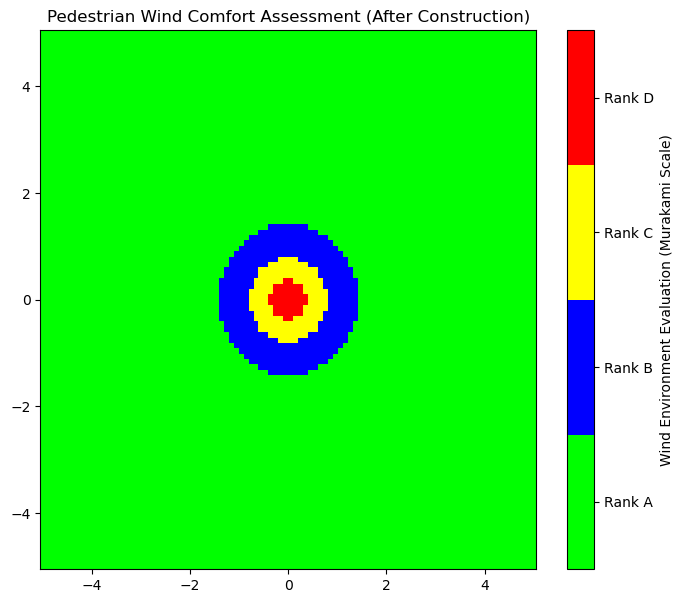

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1. 定义评价标准的阈值 (根据你提供的图片表格)
# 这里的简化逻辑：假设我们计算了 55% 累积频率对应的风速值 V55
def get_rank(v55):
    if v55 <= 1.2: return 0  # 领域 A (绿色)
    if v55 <= 1.8: return 1  # 领域 B (蓝色)
    if v55 <= 2.3: return 2  # 领域 C (黄色)
    return 3               # 领域 D (红色)

# 2. 模拟两组 V55 数据 (CFD 结果经过气象换算后的值)
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)

# 模拟：建筑后由于角隅流产生大片 D 领域
V55_build = 1.0 + 1.5 * np.exp(-(X**2 + Y**2)) 

# 3. 将连续的速度数据转换为离散的等级 (0, 1, 2, 3)
Rank_field = np.vectorize(get_rank)(V55_build)

# 4. 自定义颜色映射 (匹配图中表格的颜色)
colors = ['#00FF00', '#0000FF', '#FFFF00', '#FF0000'] # 绿, 蓝, 黄, 红
my_cmap = ListedColormap(colors)

# 5. 绘图
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.pcolormesh(X, Y, Rank_field, cmap=my_cmap, shading='auto')

# 设置图例
cbar = plt.colorbar(im, ticks=[0.375, 1.125, 1.875, 2.625])
cbar.ax.set_yticklabels(['Rank A', 'Rank B', 'Rank C', 'Rank D'])
cbar.set_label('Wind Environment Evaluation (Murakami Scale)')

ax.set_title("Pedestrian Wind Comfort Assessment (After Construction)")
plt.show()

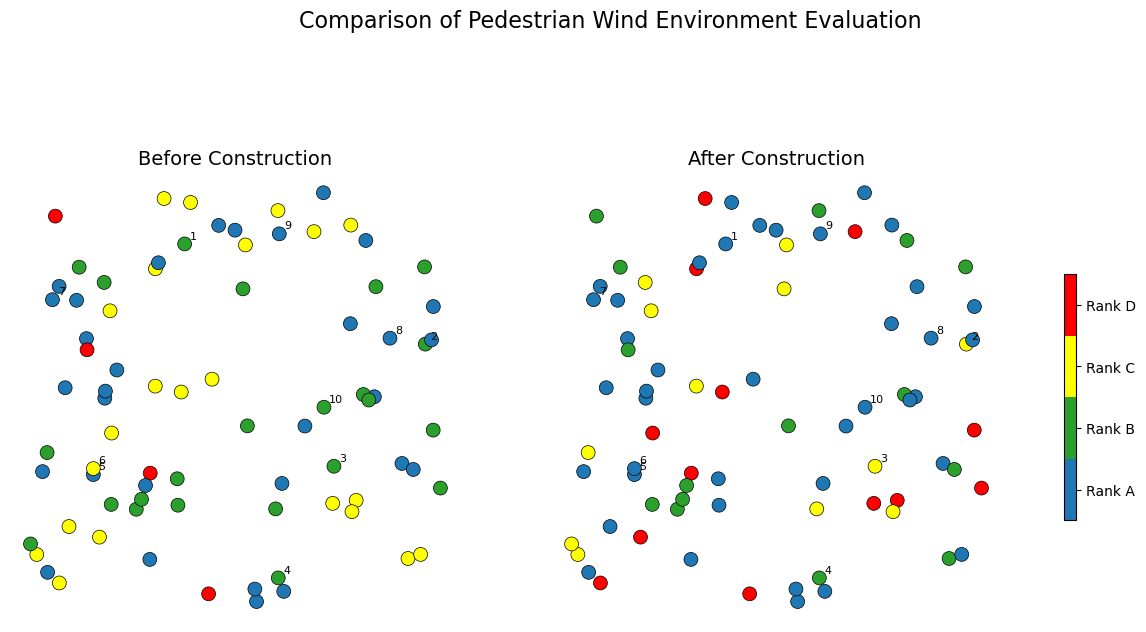

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import ListedColormap

# ----------------------------------------------------------------
# 1. 定义评价等级函数 (基于你上传的第一张图表格)
# ----------------------------------------------------------------
def get_wind_rank(v):
    """假设 v 是 55% 累积频率下的速度值"""
    if v <= 1.2: return 0  # 领域 A (住宅地) -> 蓝色/蓝色
    if v <= 1.8: return 1  # 领域 B (市街地) -> 绿色
    if v <= 2.3: return 2  # 领域 C (办公街) -> 黄色
    return 3               # 领域 D (强风区) -> 红色

# ----------------------------------------------------------------
# 2. 准备模拟数据 (实际请用 pd.read_csv 读取 Fluent 数据)
# ----------------------------------------------------------------
# 假设测点坐标 (x, y) 和对应的速度 v
np.random.seed(42)
num_points = 80
x_coords = np.random.uniform(100, 900, num_points)
y_coords = np.random.uniform(100, 900, num_points)

# 模拟建设前后的风速变化
v_pre = np.random.uniform(0.5, 2.5, num_points)
v_post = v_pre * (1 + 0.3 * np.random.randn(num_points)) # 建设后产生扰动

# 转换为 Rank (0, 1, 2, 3)
rank_pre = np.array([get_wind_rank(v) for v in v_pre])
rank_post = np.array([get_wind_rank(v) for v in v_post])

# ----------------------------------------------------------------
# 3. 绘图设置
# ----------------------------------------------------------------
# 定义与图中一致的颜色: A(蓝色), B(绿色), C(黄色), D(红色)
# 注意：你第二张图中 A 是蓝色，B 是绿色，这里按图设置
custom_colors = ['#1f77b4', '#2ca02c', '#ffff00', '#ff0000'] 
cmap_rank = ListedColormap(custom_colors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# 载入底图 (如果没有底图，可以注释掉这部分)
# img = mpimg.imread('site_map.png') 

for ax, ranks, title in zip([ax1, ax2], [rank_pre, rank_post], ['Before Construction', 'After Construction']):
    # ax.imshow(img, extent=[0, 1000, 0, 1000], alpha=0.5) # 背景图
    
    # 绘制带边框的散点 (模拟图中效果)
    scatter = ax.scatter(x_coords, y_coords, c=ranks, cmap=cmap_rank, 
                         s=100, edgecolors='black', linewidths=0.5, vmin=-0.5, vmax=3.5)
    
    # 在点旁边标注测点编号 (如果有的话)
    for i in range(10): # 仅演示前10个
        ax.text(x_coords[i]+10, y_coords[i]+10, str(i+1), fontsize=8)

    ax.set_title(title, fontsize=14)
    ax.set_aspect('equal')
    ax.axis('off') # 隐藏坐标轴，更像地图

# 添加图例
cbar = fig.colorbar(scatter, ax=[ax1, ax2], ticks=[0, 1, 2, 3], shrink=0.4)
cbar.ax.set_yticklabels(['Rank A', 'Rank B', 'Rank C', 'Rank D'])

plt.suptitle('Comparison of Pedestrian Wind Environment Evaluation', fontsize=16)
plt.show()